In [57]:
import pandas as pd
import numpy as np

In [58]:
data = pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/dsプログラミング/mine/macro_monthly.csv')
data.head()

,Year,Month,Industrial Production,Consumer Price Index,Unemployment Rate,Retail Sales,Producer Price Index,Personal Consumption Expenditures,"All Employees, Total Nonfarm",Building Permits,Money Supply (M2),Personal Income,Trade Balance,Consumer Sentiment
0,1993,1,0.39,0.35,-1.35,1.16,0.34,0.24,0.26,0.09,-0.16,-2.51,30.91,-1.87
1,1993,2,0.48,0.21,-2.74,-0.78,0.34,0.15,0.23,-2.46,-0.13,0.61,7.10,-3.02
2,1993,3,-0.10,0.14,-1.41,-0.83,0.25,0.20,-0.04,-8.01,-0.08,-0.05,-88.46,-0.81
3,1993,4,0.28,0.35,1.43,2.58,0.51,0.27,0.27,4.55,-0.01,1.02,4.90,-0.35
4,1993,5,-0.37,0.28,0.00,0.95,0.34,0.31,0.25,0.72,0.75,0.29,32.21,-6.19


In [59]:
data.describe()

,Year,Month,Industrial Production,Consumer Price Index,Unemployment Rate,Retail Sales,Producer Price Index,Personal Consumption Expenditures,"All Employees, Total Nonfarm",Building Permits,Money Supply (M2),Personal Income,Trade Balance,Consumer Sentiment
count,385.000000,385.000000,385.000000,385.000000,385.000000,385.00000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000
mean,2008.542857,6.485714,0.128987,0.210260,0.198935,0.38761,0.209792,0.173844,0.099922,0.183948,0.480390,0.402416,-1.437065,0.067662
std,9.271308,3.463414,1.043778,0.276419,12.546896,1.76661,1.102592,0.201483,0.749495,4.988710,0.566267,1.661413,11.563867,5.070688
min,1993.000000,1.000000,-13.240000,-1.770000,-17.650000,-14.52000,-5.330000,-1.180000,-13.570000,-21.950000,-1.160000,-12.950000,-88.460000,-19.420000
25%,2001.000000,3.000000,-0.180000,0.070000,-2.220000,-0.15000,-0.250000,0.070000,0.060000,-2.730000,0.230000,0.220000,-6.300000,-2.640000
50%,2009.000000,6.000000,0.190000,0.210000,0.000000,0.39000,0.230000,0.170000,0.140000,0.090000,0.440000,0.400000,-0.930000,0.000000
75%,2017.000000,9.000000,0.550000,0.330000,1.790000,0.90000,0.770000,0.290000,0.210000,3.080000,0.630000,0.550000,4.230000,3.000000
max,2025.000000,12.000000,6.580000,1.380000,236.360000,18.78000,3.210000,0.970000,3.480000,18.590000,6.370000,20.810000,34.920000,13.700000


In [60]:
data.isnull().sum()

Year                                 0
Month                                0
Industrial Production                0
Consumer Price Index                 0
Unemployment Rate                    0
Retail Sales                         0
Producer Price Index                 0
Personal Consumption Expenditures    0
All Employees, Total Nonfarm         0
Building Permits                     0
Money Supply (M2)                    0
Personal Income                      0
Trade Balance                        0
Consumer Sentiment                   0
dtype: int64

列の説明

年: 観測の年。

月: 観測月 (1-12)。

工業生産: 米国の工場、鉱山、公益事業の総生産量に関する月次データ。

消費者物価指数(CPIAUCSL): 都市部の消費者が消費財およびサービスの市場バスケットに対して支払う価格の、時間の経過に伴う平均変化の尺度。

失業率: 失業中だが積極的に就職活動を行っている労働力全体の割合。

小売売上高: 小売店の総収入。消費者の支出と経済活動を示します。

生産者物価指数: 国内生産者が生産物に対して受け取る販売価格の時間の経過に伴う平均変化を測定します。

個人消費支出: 消費者が商品やサービスに対して支払う価格の尺度であり、インフレの計算に使用されます。

全従業員、合計非農業部門: 非農業部門の雇用者数。労働市場の重要な指標です。

建築許可：住宅および非住宅の建物に対して発行された建築許可の数。

マネーサプライ: 現金、当座預金、簡単に交換できる近似通貨を含むマネーサプライの合計。

個人所得: 個人があらゆる収入源から受け取る所得の合計。

貿易収支: 国の輸入と輸出の差。

消費者信頼感：消費者の感情と将来の経済見通しに対する期待を反映する指数。

金利に関する注記
フェデラル ファンド実効金利 (FEDFUNDS) の場合、データセットには変化率ではなく、ベーシス ポイント (bps) での絶対的な変化が含まれています。つまり、データセットは前月比のパーセンテージ変化ではなく、金利の直接的な変化を反映しています。変化はベーシス ポイントで表され、1 ベーシス ポイントは 0.01% に相当します。

In [61]:
data["YearMonth"] = data["Year"].astype(str) + "-" + data["Month"].astype(str)
data.head()

,Year,Month,Industrial Production,Consumer Price Index,Unemployment Rate,Retail Sales,Producer Price Index,Personal Consumption Expenditures,"All Employees, Total Nonfarm",Building Permits,Money Supply (M2),Personal Income,Trade Balance,Consumer Sentiment,YearMonth
0,1993,1,0.39,0.35,-1.35,1.16,0.34,0.24,0.26,0.09,-0.16,-2.51,30.91,-1.87,1993-1
1,1993,2,0.48,0.21,-2.74,-0.78,0.34,0.15,0.23,-2.46,-0.13,0.61,7.10,-3.02,1993-2
2,1993,3,-0.10,0.14,-1.41,-0.83,0.25,0.20,-0.04,-8.01,-0.08,-0.05,-88.46,-0.81,1993-3
3,1993,4,0.28,0.35,1.43,2.58,0.51,0.27,0.27,4.55,-0.01,1.02,4.90,-0.35,1993-4
4,1993,5,-0.37,0.28,0.00,0.95,0.34,0.31,0.25,0.72,0.75,0.29,32.21,-6.19,1993-5


景気の好不況分類
目的：過去の指標から「景気が好況 or 不況」を分類する
ラベルの作成例：
Unemployment Rate が 5% 以上 → 不況 (1)
Unemployment Rate が 5% 未満 → 好況 (0)
モデル：
ロジスティック回帰 / ランダムフォレスト / XGBoost
特徴量：
Consumer Sentiment
Money Supply (M2)
Retail Sales

不景気になるとUnemployment Rateが多くなる
後継になるとUnemployment Rateが低くなる

In [62]:
## Unemplyayment Rateが先月との変化の差を求める
data["Unemployment Rate Change"] = data["Unemployment Rate"].diff()
## diffを持ちることによって先月との差を求めることができる
data.head()

,Year,Month,Industrial Production,Consumer Price Index,Unemployment Rate,Retail Sales,Producer Price Index,Personal Consumption Expenditures,"All Employees, Total Nonfarm",Building Permits,Money Supply (M2),Personal Income,Trade Balance,Consumer Sentiment,YearMonth,Unemployment Rate Change
0,1993,1,0.39,0.35,-1.35,1.16,0.34,0.24,0.26,0.09,-0.16,-2.51,30.91,-1.87,1993-1,NaN
1,1993,2,0.48,0.21,-2.74,-0.78,0.34,0.15,0.23,-2.46,-0.13,0.61,7.10,-3.02,1993-2,-1.39
2,1993,3,-0.10,0.14,-1.41,-0.83,0.25,0.20,-0.04,-8.01,-0.08,-0.05,-88.46,-0.81,1993-3,1.33
3,1993,4,0.28,0.35,1.43,2.58,0.51,0.27,0.27,4.55,-0.01,1.02,4.90,-0.35,1993-4,2.84
4,1993,5,-0.37,0.28,0.00,0.95,0.34,0.31,0.25,0.72,0.75,0.29,32.21,-6.19,1993-5,-1.43


In [63]:
## Unemployment Rateがプラスだったら1、マイナスだったら0を返す
data["Economic Assessment"] = np.where(data["Unemployment Rate"] > 0, 1, 0)
## 0,1のデータを持つUnemployment Rate Changeを使って、Unemployment Rateが上昇した月を求める
data.head()


,Year,Month,Industrial Production,Consumer Price Index,Unemployment Rate,Retail Sales,Producer Price Index,Personal Consumption Expenditures,"All Employees, Total Nonfarm",Building Permits,Money Supply (M2),Personal Income,Trade Balance,Consumer Sentiment,YearMonth,Unemployment Rate Change,Economic Assessment
0,1993,1,0.39,0.35,-1.35,1.16,0.34,0.24,0.26,0.09,-0.16,-2.51,30.91,-1.87,1993-1,NaN,0
1,1993,2,0.48,0.21,-2.74,-0.78,0.34,0.15,0.23,-2.46,-0.13,0.61,7.10,-3.02,1993-2,-1.39,0
2,1993,3,-0.10,0.14,-1.41,-0.83,0.25,0.20,-0.04,-8.01,-0.08,-0.05,-88.46,-0.81,1993-3,1.33,0
3,1993,4,0.28,0.35,1.43,2.58,0.51,0.27,0.27,4.55,-0.01,1.02,4.90,-0.35,1993-4,2.84,1
4,1993,5,-0.37,0.28,0.00,0.95,0.34,0.31,0.25,0.72,0.75,0.29,32.21,-6.19,1993-5,-1.43,0


In [64]:
data["Economic Assessment"].value_counts()

Economic Assessment
0    268
1    117
Name: count, dtype: int64

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# データの読み込み（例: CSVファイル）
# data = pd.read_csv("your_data.csv")

# 特徴量と目的変数を分離
X = data.drop(columns=["Economic Assessment", "YearMonth", "Year", "Month"])
y = data["Economic Assessment"]

# 欠損値処理（欠損値を中央値で埋める）
X = X.fillna(X.median())

# データの標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# データを訓練用とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ロジスティック回帰モデルの作成と学習
model = LogisticRegression()
model.fit(X_train, y_train)

# 予測と評価
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9090909090909091
              precision    recall  f1-score   support

           0       0.89      0.98      0.94        52
           1       0.95      0.76      0.84        25

    accuracy                           0.91        77
   macro avg       0.92      0.87      0.89        77
weighted avg       0.91      0.91      0.91        77



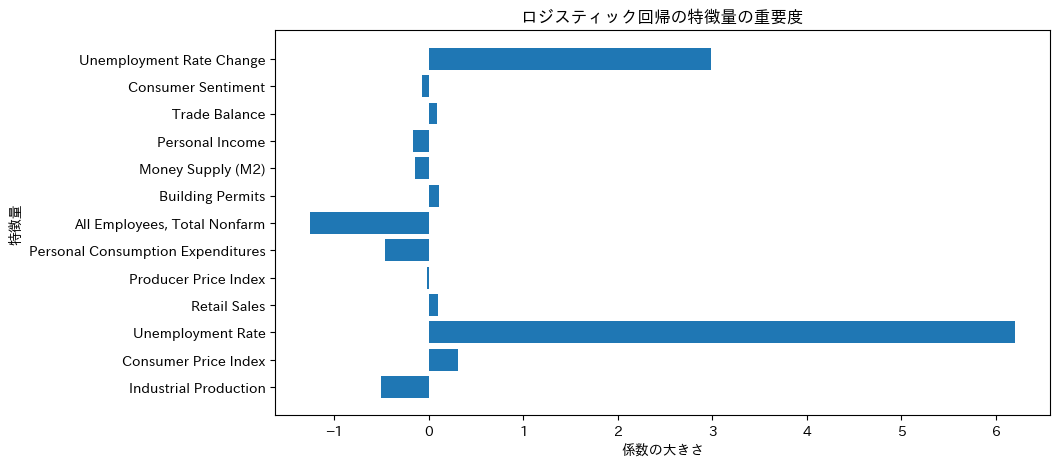

In [66]:
import matplotlib.pyplot as plt
import japanize_matplotlib
# 係数の取得
coefs = model.coef_[0]
features = X.columns

# 可視化
plt.figure(figsize=(10, 5))
plt.barh(features, coefs)
plt.xlabel("係数の大きさ")
plt.ylabel("特徴量")
plt.title("ロジスティック回帰の特徴量の重要度")
plt.show()


accuracyはモデルの予測確率を表す
Precision (適合率)**Precision (適合率)**は、モデルが予測した正のクラス（1）や負のクラス（0）のうち、どれだけ実際に正しかったかを示します。
Recall (再現率)Recall (再現率) は、実際にクラス 1 や 0 であるデータのうち、どれだけ正しく予測したかを示します。

In [67]:
# 特徴量の重要度（係数）を表示
coefficients = model.coef_[0]  # モデルの係数を取得
feature_names = X.columns  # 特徴量の名前を取得

# 特徴量とその重要度（係数）のデータフレームを作成
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# 重要度の高い順に並べ替え
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# 結果を表示
print("\nFeature importance based on the coefficients:")
print(importance_df[['Feature', 'Coefficient']])


Feature importance based on the coefficients:
                              Feature  Coefficient
2                   Unemployment Rate     6.200251
12           Unemployment Rate Change     2.988652
6        All Employees, Total Nonfarm    -1.254757
0               Industrial Production    -0.502475
5   Personal Consumption Expenditures    -0.469481
1                Consumer Price Index     0.303414
9                     Personal Income    -0.171443
8                   Money Supply (M2)    -0.149003
7                    Building Permits     0.110834
3                        Retail Sales     0.099337
10                      Trade Balance     0.085757
11                 Consumer Sentiment    -0.069886
4                Producer Price Index    -0.016627


0,1の判断する材料が少ないので条件式をもっと複雑する
また 特徴量の重要度を可視化
 他の変数も考慮した特徴量エンジニアリング

In [68]:
data["Economic Assessment"] = np.where(
    (data["Unemployment Rate"] > 0) & (data["Retail Sales"] < 0), 1, 0
)


In [69]:
data.head()

,Year,Month,Industrial Production,Consumer Price Index,Unemployment Rate,Retail Sales,Producer Price Index,Personal Consumption Expenditures,"All Employees, Total Nonfarm",Building Permits,Money Supply (M2),Personal Income,Trade Balance,Consumer Sentiment,YearMonth,Unemployment Rate Change,Economic Assessment
0,1993,1,0.39,0.35,-1.35,1.16,0.34,0.24,0.26,0.09,-0.16,-2.51,30.91,-1.87,1993-1,NaN,0
1,1993,2,0.48,0.21,-2.74,-0.78,0.34,0.15,0.23,-2.46,-0.13,0.61,7.10,-3.02,1993-2,-1.39,0
2,1993,3,-0.10,0.14,-1.41,-0.83,0.25,0.20,-0.04,-8.01,-0.08,-0.05,-88.46,-0.81,1993-3,1.33,0
3,1993,4,0.28,0.35,1.43,2.58,0.51,0.27,0.27,4.55,-0.01,1.02,4.90,-0.35,1993-4,2.84,0
4,1993,5,-0.37,0.28,0.00,0.95,0.34,0.31,0.25,0.72,0.75,0.29,32.21,-6.19,1993-5,-1.43,0


In [70]:
data["Economic Assessment"].value_counts()

Economic Assessment
0    351
1     34
Name: count, dtype: int64

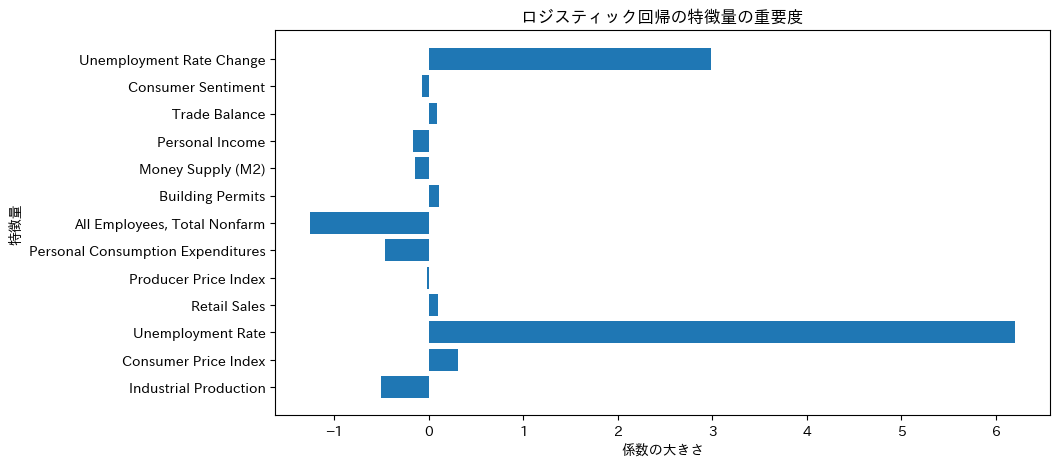

In [71]:
import matplotlib.pyplot as plt
import japanize_matplotlib
# 係数の取得
coefs = model.coef_[0]
features = X.columns

# 可視化
plt.figure(figsize=(10, 5))
plt.barh(features, coefs)
plt.xlabel("係数の大きさ")
plt.ylabel("特徴量")
plt.title("ロジスティック回帰の特徴量の重要度")
plt.show()


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00         4

    accuracy                           1.00        77
   macro avg       1.00      1.00      1.00        77
weighted avg       1.00      1.00      1.00        77



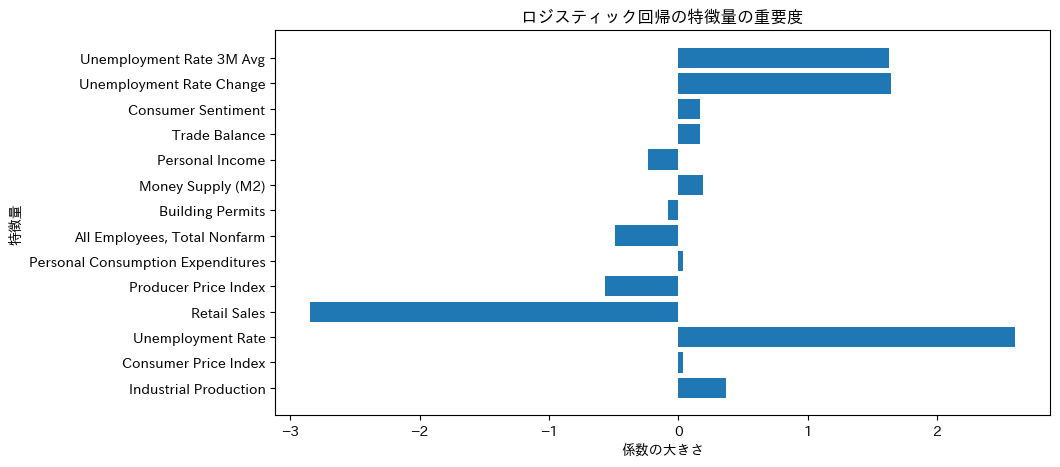

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# データの読み込み（例: CSVファイル）
# data = pd.read_csv("your_data.csv")

# 過去3ヶ月の平均失業率を特徴量に追加
data["Unemployment Rate 3M Avg"] = data["Unemployment Rate"].rolling(window=3).mean()

# 欠損値処理（最初の2行は rolling の影響で NaN になるため削除）
data = data.dropna()

# 特徴量と目的変数を分離
X = data.drop(columns=["Economic Assessment", "YearMonth", "Year", "Month"])
y = data["Economic Assessment"]

# データの標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# データを訓練用とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ロジスティック回帰モデルの作成と学習
model = LogisticRegression()
model.fit(X_train, y_train)

# 予測と評価
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

# 特徴量の重要度を可視化
import matplotlib.pyplot as plt
coefs = model.coef_[0]
features = X.columns

plt.figure(figsize=(10, 5))
plt.barh(features, coefs)
plt.xlabel("係数の大きさ")
plt.ylabel("特徴量")
plt.title("ロジスティック回帰の特徴量の重要度")
plt.show()

In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# データの読み込み（例: CSVファイル）
# data = pd.read_csv("your_data.csv")

# 特徴量と目的変数を分離
X = data.drop(columns=["Economic Assessment", "YearMonth", "Year", "Month", "Unemployment Rate"])
y = data["Economic Assessment"]

# 新しい特徴量を追加（過去3ヶ月の平均失業率）
data["Unemployment Rate 3M Avg"] = data["Unemployment Rate"].rolling(window=3).mean()

# 欠損値処理（中央値で埋める）
X = X.fillna(X.median())

# データの標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# クラスの不均衡を改善（SMOTEを適用）
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# データを訓練用とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# ロジスティック回帰モデルの作成（正則化C=0.1で過学習を防ぐ）
model = LogisticRegression(C=0.1, penalty="l2", random_state=42)
model.fit(X_train, y_train)

# 予測と評価
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("Accuracy:", accuracy)
print("ROC-AUC Score:", roc_auc)
print(classification_report(y_test, y_pred))

# クロスバリデーションで汎化性能を確認
cv_scores = cross_val_score(model, X_resampled, y_resampled, cv=5, scoring="accuracy")
print("Cross-validation Accuracy:", cv_scores.mean())


Accuracy: 0.8428571428571429
ROC-AUC Score: 0.9516635279347143
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        81
           1       0.78      0.86      0.82        59

    accuracy                           0.84       140
   macro avg       0.84      0.85      0.84       140
weighted avg       0.85      0.84      0.84       140

Cross-validation Accuracy: 0.8968550873586846


/Users/yugo_suzuki/Lecture/MD/.venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


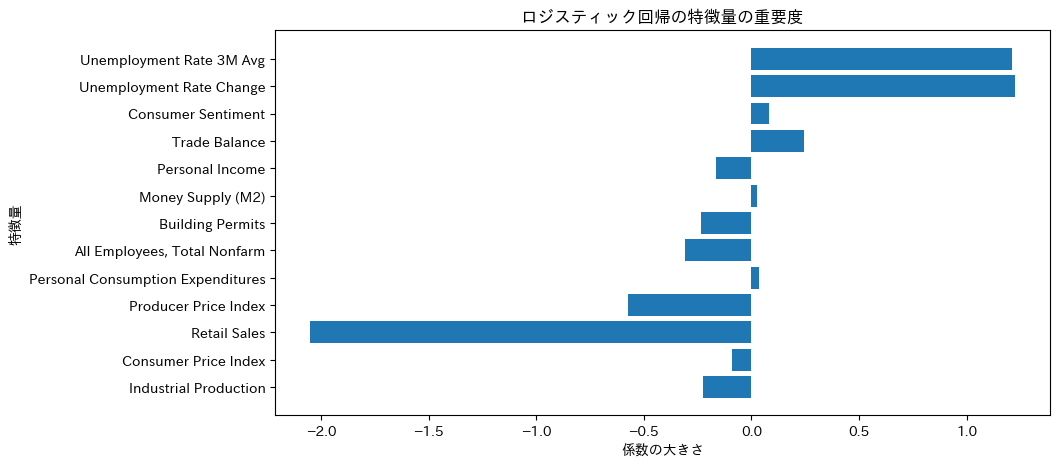

In [74]:
# 特徴量の重要度を可視化
import matplotlib.pyplot as plt
coefs = model.coef_[0]
features = X.columns

plt.figure(figsize=(10, 5))
plt.barh(features, coefs)
plt.xlabel("係数の大きさ")
plt.ylabel("特徴量")
plt.title("ロジスティック回帰の特徴量の重要度")
plt.show()